# Lab 10 — Linear Regression and Regression Metrics

In this lab you will train your first supervised machine learning model, evaluate it with three regression metrics, and inspect the coefficients it learned.

The modeling code follows a four-step pattern that you will use throughout the rest of the course. Work through each step carefully — the pattern will feel familiar quickly.

**Concepts covered:** linear regression, mean absolute error, root mean squared error, R², model coefficients, the sklearn training pipeline.

**Reference working sessions:**
- `working-sessions/supervised/01_linear_regression.ipynb`
- `working-sessions/math/statistics_for_ml/03_the_normal_equations.ipynb`
- `working-sessions/model_evaluation/01_regression_metrics.ipynb`

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tkh_utils import (
    PALETTE, FONT, base_layout,
    check_answer, make_answer_key, make_grading_summary,
    load_california_housing,
)

_ak = make_answer_key({
    'q1': 'B',
    'q2': 'B',
    'q3': 'B',
    'q4': 'C',
})

---
## Section A — Multiple Choice

Fill in each answer variable with the letter of the best answer (A, B, C, or D).

In [6]:
# Q1 — Mean Squared Error (MSE) penalizes large prediction errors more heavily
# than Mean Absolute Error (MAE). Why?
#
#   A) MSE divides by n-1 instead of n, which amplifies larger values
#   B) Squaring the residuals causes large errors to contribute disproportionately
#      more to the total
#   C) MSE sums residuals before squaring, while MAE takes the square root first
#   D) MSE counts each error twice by summing over both training and test sets

q1_answer = "B"  # Replace with A, B, C, or D

assert q1_answer != "___", "Don't forget to fill in your answer!"
assert check_answer(q1_answer, _ak['q1']), \
    "Not quite — revisit working-sessions/model_evaluation/01_regression_metrics.ipynb. " \
    "Move the error slider to a large value and compare how MSE and MAE respond."
print("\u2713 Question 1 correct!")

✓ Question 1 correct!


In [10]:
# Q2 — A model reports R\u00b2 = 0.72. What does this mean?
#
#   A) 72% of the model's predictions are within one unit of the true value
#   B) The model explains 72% of the variance in the target variable
#   C) The correlation between predicted and actual values is 0.72
#   D) 72% of residuals fall within one standard deviation of zero

q2_answer = "B"  # Replace with A, B, C, or D

assert q2_answer != "___", "Don't forget to fill in your answer!"
assert check_answer(q2_answer, _ak['q2']), \
    "Not quite — revisit working-sessions/model_evaluation/01_regression_metrics.ipynb. " \
    "R\u00b2 measures how much of the variance your model accounts for."
print("\u2713 Question 2 correct!")

✓ Question 2 correct!


In [13]:
# Q3 — A linear regression model predicts house prices. The coefficient for
# 'number of rooms' is 15,000. What does this mean?
#
#   A) Houses with more rooms are 15,000 times more expensive than the baseline
#   B) Adding one room is associated with a $15,000 increase in predicted price,
#      holding all other features constant
#   C) 15,000 is the probability that number of rooms influences the price
#   D) The model is 15,000 units confident in its room-size prediction

q3_answer = "B"  # Replace with A, B, C, or D

assert q3_answer != "___", "Don't forget to fill in your answer!"
assert check_answer(q3_answer, _ak['q3']), \
    "Not quite — revisit working-sessions/supervised/01_linear_regression.ipynb. " \
    "A coefficient tells you the expected change in y for a one-unit change in that feature."
print("\u2713 Question 3 correct!")

✓ Question 3 correct!


In [14]:
# Q4 — When would you prefer gradient descent over the normal equations
# (\u03b2 = (X\u1d40 X)\u207b\u00b9 X\u1d40 y) to solve linear regression?
#
#   A) When the dataset has fewer than 100 rows — small datasets require iteration
#   B) When you need an exact closed-form solution with no approximation error
#   C) When the number of features is very large — computing the matrix inverse
#      becomes prohibitively expensive
#   D) When the target variable is categorical rather than continuous

q4_answer = "C"  # Replace with A, B, C, or D

assert q4_answer != "___", "Don't forget to fill in your answer!"
assert check_answer(q4_answer, _ak['q4']), \
    "Not quite — revisit working-sessions/math/statistics_for_ml/03_the_normal_equations.ipynb. " \
    "The normal equations require inverting X\u1d40X, which costs O(p\u00b3) in the number of features."
print("\u2713 Question 4 correct!")

✓ Question 4 correct!


In [15]:
make_grading_summary([
    (q1_answer, _ak['q1'], "Q1: Why MSE penalizes large errors more than MAE"),
    (q2_answer, _ak['q2'], "Q2: Interpreting R\u00b2 = 0.72"),
    (q3_answer, _ak['q3'], "Q3: What a regression coefficient means"),
    (q4_answer, _ak['q4'], "Q4: When to prefer gradient descent over normal equations"),
], total=4)

Section A Results:
✓ Q1: Why MSE penalizes large errors more than MAE
✓ Q2: Interpreting R² = 0.72
✓ Q3: What a regression coefficient means
✓ Q4: When to prefer gradient descent over normal equations

Score: 4/4
----------------------------------------
🎉 Perfect score on Section A!

Section B & C: check ✓ marks above
Section D: for your own reflection


---
## Section B — Coding Exercises

The three exercises below walk you through the complete workflow for training and evaluating a linear regression model. Run them in order — each step builds on the previous one.

Run the setup cell first.

In [16]:
# Shared setup — run this before the exercises
X, y = load_california_housing()

print("Dataset shape:", X.shape)
print("Features:", X.columns.tolist())
print(f"Target range: ${y.min():.2f}  to  ${y.max():.2f}  (in $100k units)")
print(f"Target mean:  ${y.mean():.2f}")

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: $0.15  to  $5.00  (in $100k units)
Target mean:  $2.07


### B1 — The sklearn regression pipeline

The four steps below form the complete pattern for training a supervised model in scikit-learn. Fill in the blanks to complete each step.

In [17]:
# B1 — Complete the sklearn linear regression pipeline

# Step 1 — Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # YOUR CODE — 20% test, seed=42
)

# Step 2 — Create the model
model = LinearRegression()   # YOUR CODE — instantiate LinearRegression

# Step 3 — Train the model
model.fit(X_train, y_train)   # YOUR CODE — pass training features and labels

# Step 4 — Generate predictions
y_pred = model.predict(X_test)   # YOUR CODE — predict on the test set

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Predictions      : {y_pred.shape[0]} values")
print(f"First 5 predicted: {y_pred[:5].round(2)}")
print(f"First 5 actual   : {y_test.values[:5].round(2)}")

# --- checks ---
assert X_train.shape[0] + X_test.shape[0] == len(X), \
    "train + test should equal total samples"
assert hasattr(model, 'coef_'), \
    "model.coef_ is not available — did you call model.fit()?"
assert y_pred.shape == y_test.shape, \
    "y_pred and y_test must have the same shape — predict on X_test"
print("\u2713 B1 complete!")

Training samples : 16512
Test samples     : 4128
Predictions      : 4128 values
First 5 predicted: [0.72 1.76 2.71 2.84 2.6 ]
First 5 actual   : [0.48 0.46 5.   2.19 2.78]
✓ B1 complete!


### B2 — Compute regression metrics

Three numbers tell you most of what you need to know about a regression model: how far off it is on average (MAE), how much it is penalized for large mistakes (RMSE), and how much of the variance it explains (R\u00b2).

In [18]:
# B2 — Compute MAE, RMSE, and R\u00b2
#
# Fill in the metric function names and arguments.
# y_pred is already available from B1 above.

mae  = mean_absolute_error(y_test, y_pred)               # YOUR CODE — mean absolute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))      # YOUR CODE — root mean squared error
r2   = r2_score(y_test, y_pred)              # YOUR CODE — R\u00b2 score

print(f"MAE  : {mae:.3f}  ($100k units — average absolute prediction error)")
print(f"RMSE : {rmse:.3f}  ($100k units — penalizes large errors more)")
print(f"R\u00b2   : {r2:.3f}   (fraction of variance explained)")

# --- checks ---
assert isinstance(mae, float), \
    "MAE should be a float — use mean_absolute_error(y_test, y_pred)"
assert isinstance(rmse, float), \
    "RMSE should be a float — use np.sqrt(mean_squared_error(y_test, y_pred))"
assert isinstance(r2, float), \
    "R\u00b2 should be a float — use r2_score(y_test, y_pred)"
assert rmse >= mae, \
    "RMSE is always >= MAE — check that you computed both correctly"
assert 0 < r2 < 1, \
    "R\u00b2 should be between 0 and 1 for this dataset — check that you passed (y_test, y_pred)"
print("\u2713 B2 complete!")

MAE  : 0.533  ($100k units — average absolute prediction error)
RMSE : 0.746  ($100k units — penalizes large errors more)
R²   : 0.576   (fraction of variance explained)
✓ B2 complete!


### B3 — Inspect model coefficients

After training, linear regression stores one coefficient per feature. These tell you how each feature influences the prediction — and which features the model is relying on most heavily.

In [19]:
# B3 — Extract and rank model coefficients
#
# Build a Series that maps each feature name to its learned coefficient,
# then sort by absolute value to see which features the model weighted most.

feature_names = X.columns.tolist()

coef_series = pd.Series(model.coef_, index=feature_names)              # YOUR CODE — model.coef_, feature_names
coef_ranked = coef_series.abs().sort_values(ascending=False)  # YOUR CODE — True or False

top_feature = coef_ranked.index[0]

print("Feature coefficients (ranked by absolute value):")
for feat in coef_ranked.index:
    coef_val = coef_series[feat]
    print(f"  {feat:<14} {coef_val:+.4f}")

print(f"\nModel intercept       : {model.intercept_:.4f}")
print(f"Highest-weight feature: {top_feature}")

# --- checks ---
assert isinstance(coef_series, pd.Series), \
    "coef_series should be a pandas Series — use pd.Series(model.coef_, index=feature_names)"
assert len(coef_series) == len(feature_names), \
    "coef_series should have one value per feature"
assert coef_ranked.index[0] == 'AveBedrms', \
    "Sort descending by absolute value — check ascending=False"
print("\u2713 B3 complete!")

Feature coefficients (ranked by absolute value):
  AveBedrms      +0.7831
  MedInc         +0.4487
  Longitude      -0.4337
  Latitude       -0.4198
  AveRooms       -0.1233
  HouseAge       +0.0097
  AveOccup       -0.0035
  Population     -0.0000

Model intercept       : -37.0233
Highest-weight feature: AveBedrms
✓ B3 complete!


---
## Section C — Applied Problem

Put everything together. Starting from scratch — load, split, fit, predict, evaluate, visualize. The cells below give you a structure; your job is to complete the code so it runs end-to-end.

California Housing — Linear Regression Results
  MAE  : 0.535
  RMSE : 0.727
  R²   : 0.594


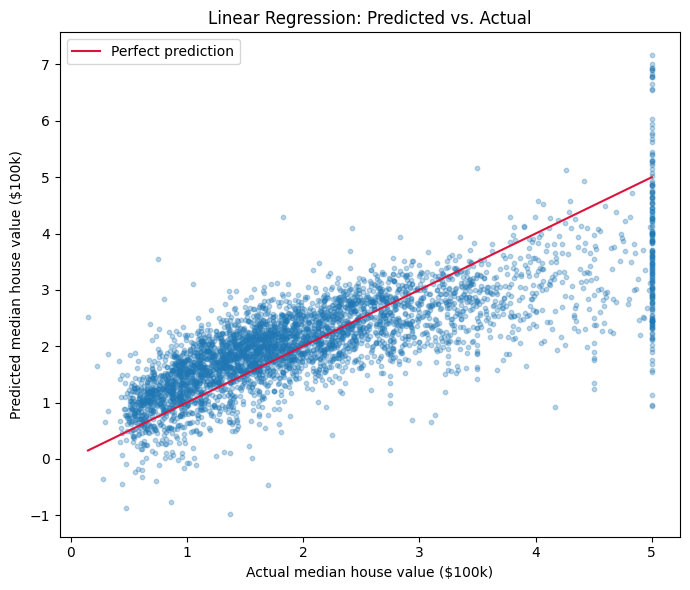

✓ Section C complete!
  The model explains 59.4% of the variance in California house prices.


In [20]:
# Section C — End-to-end linear regression pipeline

# --- Step 1: Load data ---
X_c, y_c = load_california_housing()

# --- Step 2: Split (80% train, 20% test, random_state=0) ---
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=0   # YOUR CODE
)

# --- Step 3: Fit a linear regression model ---
lr = LinearRegression()              # YOUR CODE — create the model
lr.fit(X_c_train, y_c_train)        # YOUR CODE — train it

# --- Step 4: Predict ---
y_c_pred = lr.predict(X_c_test)   # YOUR CODE

# --- Step 5: Compute metrics ---
c_mae  = mean_absolute_error(y_c_test, y_c_pred)         # YOUR CODE
c_rmse = np.sqrt(mean_squared_error(y_c_test, y_c_pred)) # YOUR CODE
c_r2   = r2_score(y_c_test, y_c_pred)                    # YOUR CODE

print("California Housing — Linear Regression Results")
print(f"  MAE  : {c_mae:.3f}")
print(f"  RMSE : {c_rmse:.3f}")
print(f"  R\u00b2   : {c_r2:.3f}")

# --- Step 6: Predicted vs. actual scatter plot ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_c_test, y_c_pred, alpha=0.3, s=10)
ax.plot([y_c_test.min(), y_c_test.max()],
        [y_c_test.min(), y_c_test.max()],
        color='crimson', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel("Actual median house value ($100k)")
ax.set_ylabel("Predicted median house value ($100k)")
ax.set_title("Linear Regression: Predicted vs. Actual")
ax.legend()
plt.tight_layout()
plt.show()

# --- Section C checks ---
assert c_r2 > 0.5, \
    f"R\u00b2 should be above 0.5 for this dataset — got {c_r2:.3f}. Check your fit and predict calls."
assert isinstance(c_rmse, float) and c_rmse > 0, \
    "RMSE should be a positive float"
assert c_rmse >= c_mae, \
    "RMSE is always >= MAE — check your metric calculations"
assert len(ax.collections) > 0 or len(ax.lines) >= 2, \
    "Complete the scatter plot — ax.scatter(...) should have run"
print("\u2713 Section C complete!")
print(f"  The model explains {c_r2 * 100:.1f}% of the variance in California house prices.")

---

## Section D — Reflection

These questions are for reflection. Edit the markdown cells below each question to write your response. There are no wrong answers — we are looking for thoughtful engagement with what you have learned. Your instructor may review these.

**Question D1**

Your model shows MAE = 2.4 and RMSE = 8.1 (in $100k units). The gap between these two metrics is unusually large. What does this tell you about the kinds of errors the model is making?

RMSE squares errors before averaging then takes the square root, so large individual errors get amplified much more than in MAE, which just averages absolute values linearly. A gap this big (MAE 2.4 vs RMSE 8.1) means the average-sized error is small, but a handful of predictions are wildly off. The model is mostly close but occasionally makes very large mistakes on specific points, rather than being uniformly a little wrong everywhere.

**Question D2**

A colleague says: "Our model has R² = 0.95, so it's definitely a good model." What questions would you ask before agreeing?

What does R² actually measure?
What could a single aggregate number hide?

**Question D3**

Looking at the scatter plot from Section C, where do most prediction errors occur — near the center of the distribution or at the extremes? Why might linear regression struggle at the extremes?

Predictions are pretty accurate near the middle of the price range, but get much worse at the extremes, especially around actual value 5, where predictions swing anywhere from 1 to 7. That's partly because California caps housing values at $500k, so all the truly expensive houses get lumped into the same "5.0" label, making them impossible to predict exactly. It's also because linear regression fits one straight line across the whole dataset, so if prices don't actually change linearly at the high or low end, the model will systematically miss in those areas.